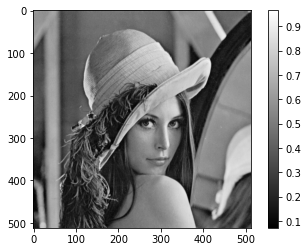

(<Figure size 432x288 with 2 Axes>,
 None)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io

img = io.imread('lena.png')
Y = color.rgb2gray(img)
plt.figure(),plt.imshow(Y,cmap='gray'), plt.colorbar(),plt.show()

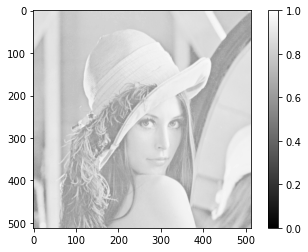

(<Figure size 432x288 with 2 Axes>,
 None)

In [6]:
Yout = (Y)**(0.25)
plt.figure(),plt.imshow(Yout,cmap='gray',vmin=0, vmax=1), plt.colorbar(),plt.show()

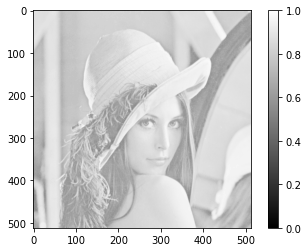

(<Figure size 432x288 with 2 Axes>,
 None)

In [18]:
def T(grayin,r):
    grayout= grayin**r
    return grayout

LUT = np.zeros((256))
for i in range(0,256):
    LUT[i]=T(i/255.0, 0.25)

[L,C]=np.shape(Y)
Yout2 = np.zeros((L,C))
for l in range(0,L):
    for c in range(0,C):
        #Yout2[l,c]=(Y[l,c])**0.25
        #Yout2[l,c]=T(Y[l,c])
        Yout2[l,c]=LUT[np.uint8(255*Y[l,c])]
        
        
plt.figure(),plt.imshow(Yout2,cmap='gray',vmin=0, vmax=1), plt.colorbar(),plt.show()

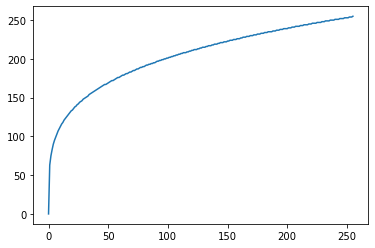

(<Figure size 432x288 with 1 Axes>,
 None)

In [19]:
plt.figure(),plt.plot(np.uint8(255*LUT)),plt.show()

In [23]:
def T(grayin,r):
    grayout= grayin**r
    return grayout

def prelucrare_scalara(Y): 
    LUT = np.zeros((256))
    for i in range(0,256):
        LUT[i]=T(i/255.0, 5)

    [L,C]=np.shape(Y)
    Yout2 = np.zeros((L,C))
    for l in range(0,L):
        for c in range(0,C):
            Yout2[l,c]=LUT[np.uint8(255*Y[l,c])]
    return Yout2

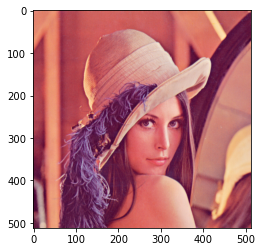

(<Figure size 432x288 with 1 Axes>,
 None)

In [21]:
plt.figure(),plt.imshow(img),plt.show()

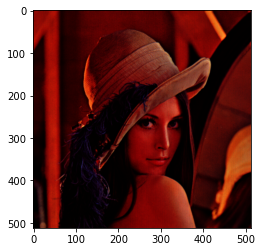

(<Figure size 432x288 with 1 Axes>,
 None)

In [24]:
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]
Rout = prelucrare_scalara(R/255.0)
Gout = prelucrare_scalara(G/255.0)
Bout = prelucrare_scalara(B/255.0)
imgout = np.zeros(np.shape(img))
imgout[:,:,0]=Rout
imgout[:,:,1]=Gout
imgout[:,:,2]=Bout
plt.figure(),plt.imshow(imgout),plt.show()

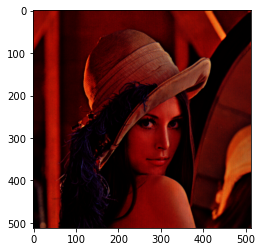

(<Figure size 432x288 with 1 Axes>,
 None)

In [25]:
plt.figure(),plt.imshow(np.uint8(255*imgout)),plt.show()

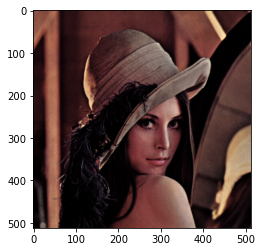

(<Figure size 432x288 with 1 Axes>,
 None)

In [28]:
hsv = color.rgb2hsv(img)
V = hsv[:,:,2]
Vout = prelucrare_scalara(V)
#S = hsv[:,:,1]
#Sout = prelucrare_scalara(S)

hsv[:,:,2]=Vout
#hsv[:,:,1]=Sout

rgbnou = color.hsv2rgb(hsv)
plt.figure(),plt.imshow(rgbnou),plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


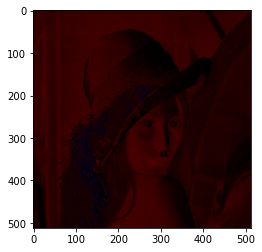

(<Figure size 432x288 with 1 Axes>,
 None)

In [29]:
ycbcr = color.rgb2ycbcr(img)
Y = ycbcr[:,:,0]
Yout = prelucrare_scalara(Y)
ycbcr[:,:,0]=Yout
rgbnou = color.ycbcr2rgb(ycbcr)
plt.figure(),plt.imshow(rgbnou),plt.show()

In [30]:
print(np.max(rgbnou))
print(np.min(rgbnou))

0.35646546393520606
-0.7744691808655771


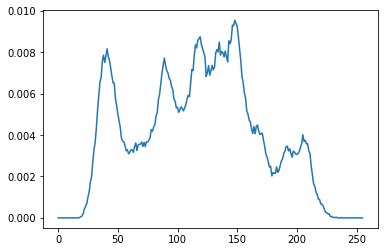

(<Figure size 432x288 with 1 Axes>,
 None)

In [33]:
img = io.imread('lena.png')
Yfloat = color.rgb2gray(img)
Y = np.uint8(255*Yfloat)

[L,C]=np.shape(Y)
contor = np.zeros((256))

for l in range(0,L):
    for c in range(0,C):
        contor[np.uint8(255*Yfloat[l,c])]+=1
        
h = contor/(L*C)
plt.figure(),plt.plot(h),plt.show()

In [34]:
hh = np.histogram(Y, 256, (0,256), density=True)

In [35]:
print(np.shape(hh))

(2,)


C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:1970: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result = asarray(a).shape


In [36]:
hh, _ = np.histogram(Y, 256, (0,256), density=True)

In [37]:
print(np.shape(hh))

(256,)


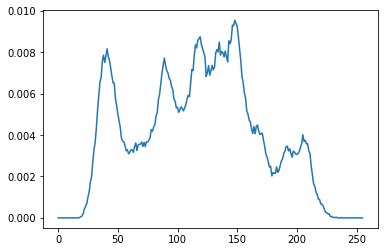

(<Figure size 432x288 with 1 Axes>,
 None)

In [38]:
plt.figure(),plt.plot(hh),plt.show()

In [39]:
hhfloat, _ = np.histogram(Yfloat, 256, (0,1.000000001), density=True)

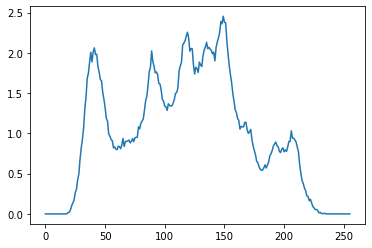

(<Figure size 432x288 with 1 Axes>,
 None)

In [41]:
plt.figure(),plt.plot(hhfloat),plt.show()

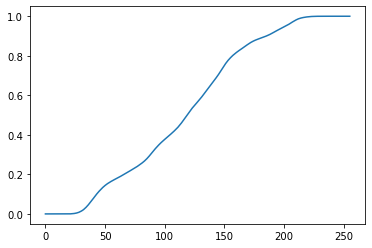

(<Figure size 432x288 with 1 Axes>,
 None)

In [42]:
H = np.cumsum(hh)
plt.figure(),plt.plot(H),plt.show()

In [43]:
def egalizare_histogama(Y):
    hhfloat, _ = np.histogram(Y, 256, (0,1.000000001), density=True)
    H = np.cumsum(hhfloat)
    [L,C]=np.shape(Y)
    Yout2 = np.zeros((L,C))
    for l in range(0,L):
        for c in range(0,C):
            Yout2[l,c]=H[np.uint8(255*Y[l,c])]
    return Yout2
    

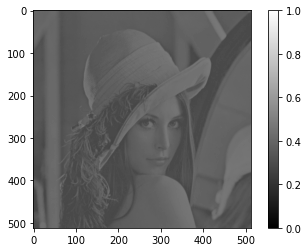

(<Figure size 432x288 with 2 Axes>,
 None)

In [51]:
Ystricat = 0.25+Yfloat/4.0
plt.figure(),plt.imshow(Ystricat,cmap='gray',vmin=0, vmax=1), plt.colorbar(),plt.show()

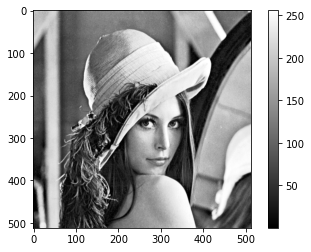

(<Figure size 432x288 with 2 Axes>,
 None)

In [52]:
Yheq=egalizare_histogama(Ystricat)
plt.figure(),plt.imshow(Yheq,cmap='gray'), plt.colorbar(),plt.show()

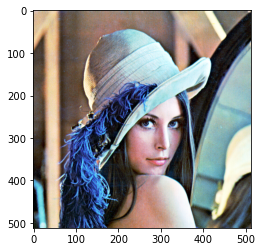

(<Figure size 432x288 with 1 Axes>,
 None)

In [53]:
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]
Rout = egalizare_histogama(R/255.0)
Gout = egalizare_histogama(G/255.0)
Bout = egalizare_histogama(B/255.0)
imgout = np.zeros(np.shape(img))
imgout[:,:,0]=Rout
imgout[:,:,1]=Gout
imgout[:,:,2]=Bout
plt.figure(),plt.imshow(np.uint8(imgout)),plt.show()